In [1]:
import numpy as np
import matplotlib.pyplot as plt
import json
from functions.plot_function import (plot_joint_trajectory,
                                     plot_joint_index,
                                     animate_joint_index)
from sklearn.decomposition import PCA
import joblib
import os

In [20]:
CASE = 'flat-10string-leftright'
TRIAL = 2
MODEL = "ff"

BASE_PATH = f'C:\\Users\\emper\\Desktop\\ICRA2026\\locomotion_learning_information-theory\\sim2real_plot\\logs\\{CASE}'
SAVE_PATH = f'C:\\Users\\emper\\Desktop\\ICRA2026\\locomotion_learning_information-theory\\sim2real_plot\\figures\\{CASE}'
os.makedirs(SAVE_PATH, exist_ok=True)
SAVE_AT = os.path.join(SAVE_PATH, f'{MODEL}-{CASE}-{TRIAL}')

data_path = os.path.join(BASE_PATH,f'{MODEL}-pos_act_model0_buffer-{TRIAL}.json')

with open(data_path, "r") as file:
    data = json.load(file)

## Selected Joint - Real-time Video

`HZ = 50` -> one timestep is 0.02 s, so the clip plays at wall-clock speed.
`WINDOW = 100` timesteps -> a 2 s scrolling view.

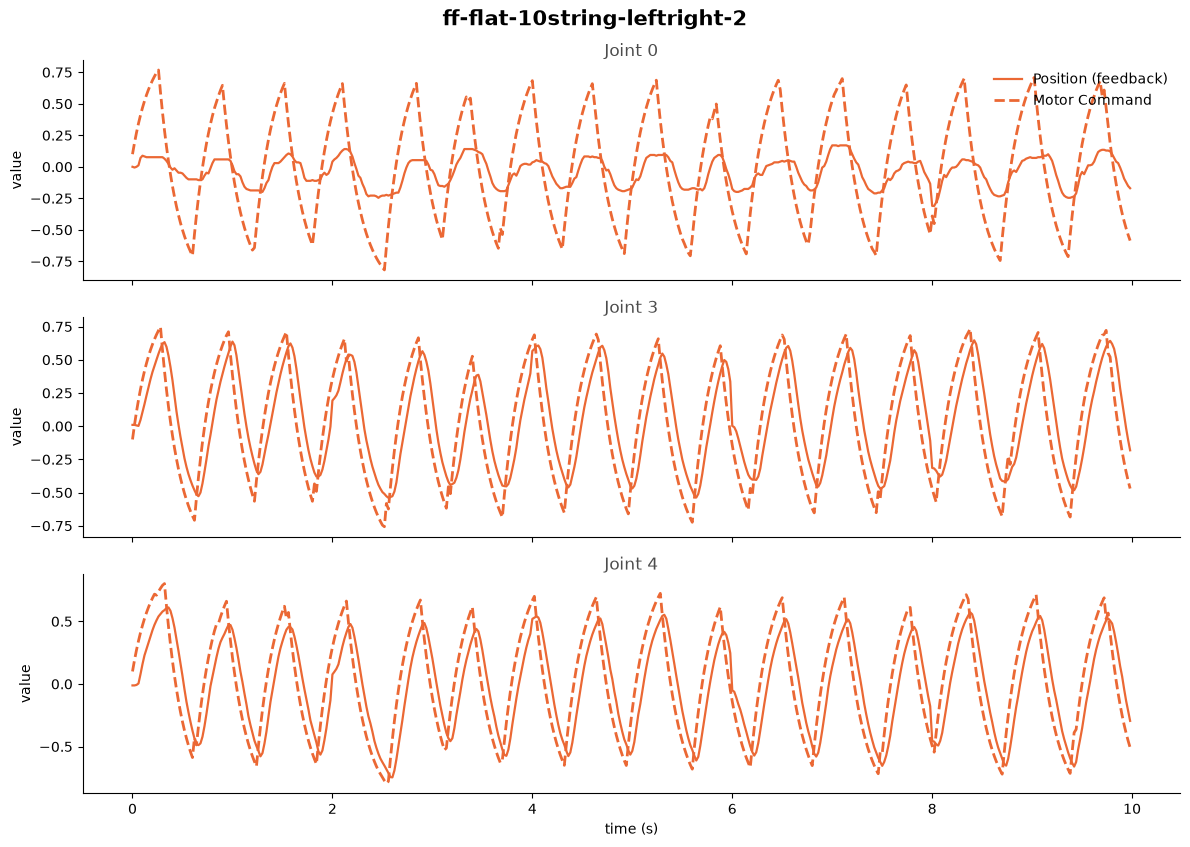

In [23]:
HZ = 50            # control rate: 1 timestep = 1/50 s
WINDOW = 100       # visible timesteps = 2.0 s at 50 Hz
JOINTS = [0, 3, 4]    # <- pick the joint index / indices here

COMPARE0 = np.array(data['pos'])[:500,:]
COMPARE1 = np.array(data['act_lowpass'])[:500,:]

# static look at the selected joints first
fig, _ = plot_joint_index(COMPARE0, COMPARE1, JOINTS, hz=HZ,
                          title_name=f"{MODEL}-{CASE}-{TRIAL}",
                          save_path=f"{SAVE_AT}-joint{JOINTS}.png")

In [17]:
# real-time scrolling video of the same joints
result = animate_joint_index(
    COMPARE0, COMPARE1, JOINTS,
    title_name=f"{MODEL}-{CASE}-{TRIAL}",
    hz=HZ,
    window=WINDOW,
    out_dir=SAVE_PATH,
    filename=f"{MODEL}-{CASE}-{TRIAL}-joint{'_'.join(map(str, JOINTS))}",
)
result


Wrote C:\Users\emper\Desktop\ICRA2026\locomotion_learning_information-theory\sim2real_plot\figures\flat-10string-leftright\ff-flat-10string-leftright-2-joint0_3_4.mp4


{'mp4': WindowsPath('C:/Users/emper/Desktop/ICRA2026/locomotion_learning_information-theory/sim2real_plot/figures/flat-10string-leftright/ff-flat-10string-leftright-2-joint0_3_4.mp4')}

In [14]:
# play the MP4 inline (relative path keeps the notebook small - no base64 embed)
from IPython.display import Video

Video(os.path.relpath(result['mp4'], os.getcwd()), embed=False, width=900)